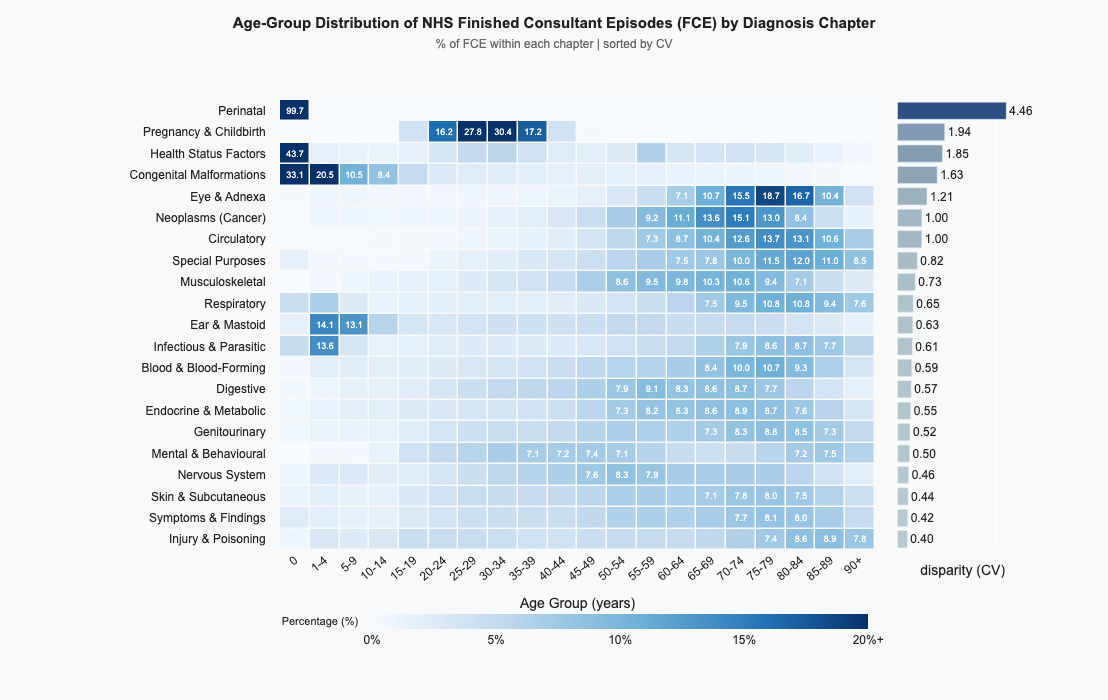

In [16]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# -- 1. Data Loading & Cleaning -----------------------------------------------
DATA_PATH = 'hosp-epis-stat-admi-diag-2015-2024.xlsx'

age_labels = ['0','1-4','5-9','10-14','15-19',
              '20-24','25-29','30-34','35-39','40-44','45-49',
              '50-54','55-59','60-64','65-69','70-74','75-79','80-84','85-89','90+']

single_ages = ['15','16','17','18','19']
_target_cols = ['0','1-4','5-9','10-14','15','16','17','18','19',
                '20-24','25-29','30-34','35-39','40-44','45-49',
                '50-54','55-59','60-64','65-69','70-74','75-79','80-84','85-89','90+']

_frames = []
xl = pd.ExcelFile(DATA_PATH)
for _sheet in xl.sheet_names:
    _df_raw = pd.read_excel(DATA_PATH, sheet_name=_sheet, header=None)
    _headers = _df_raw.iloc[0].tolist()
    _df_s = _df_raw.iloc[1:].copy()
    _df_s.columns = _headers
    _df_s = _df_s.reset_index(drop=True)
    _rename_map = {old: new for old, new in zip(_headers[4:28], _target_cols)}
    _df_s.rename(columns=_rename_map, inplace=True)
    _df_s[list(_rename_map.values())] = _df_s[list(_rename_map.values())].apply(pd.to_numeric, errors='coerce').fillna(0)
    _df_s['FCE'] = pd.to_numeric(_df_s['Finished consultant episodes(FCE)'], errors='coerce').fillna(0)
    _frames.append(_df_s)

df = pd.concat(_frames, ignore_index=True)
df['15-19'] = df[single_ages].sum(axis=1)
df.drop(columns=single_ages, inplace=True)

SHORT = {
    'Certain infectious and parasitic diseases': 'Infectious & Parasitic',
    'Neoplasms': 'Neoplasms (Cancer)',
    'Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism': 'Blood & Blood-Forming',
    'Endocrine, nutritional and metabolic diseases': 'Endocrine & Metabolic',
    'Mental and behavioural disorders': 'Mental & Behavioural',
    'Diseases of the nervous system': 'Nervous System',
    'Diseases of the eye and adnexa': 'Eye & Adnexa',
    'Diseases of the ear and mastoid process': 'Ear & Mastoid',
    'Diseases of the circulatory system': 'Circulatory',
    'Diseases of the respiratory system': 'Respiratory',
    'Diseases of the digestive system': 'Digestive',
    'Diseases of the skin and subcutaneous tissue': 'Skin & Subcutaneous',
    'Diseases of the musculoskeletal system and connective tissue': 'Musculoskeletal',
    'Diseases of the genitourinary system': 'Genitourinary',
    'Pregnancy, childbirth and the puerperium': 'Pregnancy & Childbirth',
    'Certain conditions originating in the perinatal period': 'Perinatal',
    'Congenital malformations, deformations and chromosomal abnormalities': 'Congenital Malformations',
    'Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified': 'Symptoms & Findings',
    'Injury, poisoning and certain other consequences of external causes': 'Injury & Poisoning',
    'Codes for special purposes': 'Special Purposes',
    'Factors influencing health status and contact with health services': 'Health Status Factors',
}
df['chapter_short'] = df['ICD10 chapter'].map(SHORT)

# -- 2. Aggregating Data ------------------------------------------------------
agg = df.groupby('chapter_short')[age_labels].sum()
agg_fce = df.groupby('chapter_short')['FCE'].sum()
agg_pct = agg.div(agg.sum(axis=1), axis=0) * 100
cv = agg_pct.std(axis=1) / agg_pct.mean(axis=1)

order = cv.sort_values(ascending=False).index
agg_pct = agg_pct.loc[order]
agg_abs = agg.loc[order]
cv = cv.loc[order]
fce_tot = agg_fce.loc[order]

# -- 3. Hover Tooltips & Cell Text -------------------------------------------
hover = []
for ch in agg_pct.index:
    row_hover = []
    for ag in age_labels:
        pct   = agg_pct.loc[ch, ag]
        count = int(agg_abs.loc[ch, ag])
        total = int(fce_tot[ch])
        row_hover.append(
            f"<b>{ch}</b><br>"
            f"Age group: <b>{ag}</b><br>"
            f"Share of chapter: <b>{pct:.2f}%</b><br>"
            f"FCE (this age): <b>{count:,}</b><br>"
            f"FCE (chapter total): <b>{total:,}</b>"
        )
    hover.append(row_hover)

cell_text = [[f'{agg_pct.loc[ch, ag]:.1f}' if agg_pct.loc[ch, ag] > 7 else '' for ag in age_labels] for ch in agg_pct.index]

# -- 4. Plotting --------------------------------------------------------------
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.82, 0.18],
    horizontal_spacing=0.03 
)

fig.add_trace(
    go.Heatmap(
        z=agg_pct.values,
        x=age_labels,
        y=list(agg_pct.index),
        customdata=hover,
        hovertemplate='%{customdata}',
        text=cell_text,
        texttemplate='%{text}',
        textfont=dict(size=9, color='white'),
        colorscale=[
            [0.00, '#f7fbff'], [0.25, '#c6dbef'],
            [0.55, '#6baed6'], [0.80, '#2171b5'], [1.00, '#08306b'],
        ],
        zmin=0, zmax=20,
        showscale=True,
        colorbar=dict(
            title=dict(text="Percentage (%)", font=dict(size=11), side='right'),
            thickness=15, len=0.80, x=0.40, y=-0.12,
            yref='paper', yanchor='top', orientation='h',
            tickvals=[0, 5, 10, 15, 20],
            ticktext=['0%', '5%', '10%', '15%', '20%+']
        ),
        xgap=1.5, ygap=1.5,
    ),
    row=1, col=1
)

cv_vals = cv.values
bar_colors = [f'rgba({int(8+(1-v/cv_vals.max())*180)},{int(48+(1-v/cv_vals.max())*160)},{int(107+(1-v/cv_vals.max())*100)},0.85)' for v in cv_vals]

fig.add_trace(
    go.Bar(
        x=cv_vals, y=list(cv.index),
        orientation='h', marker=dict(color=bar_colors),
        text=[f'{v:.2f}' for v in cv_vals], textposition='outside',
        cliponaxis=False, 
        showlegend=False,
    ),
    row=1, col=2
)

# -- 5. Layout Configuration --------------------------------------------------
fig.update_layout(
    title=dict(
        text=('<b>Age-Group Distribution of NHS Finished Consultant Episodes (FCE) by Diagnosis Chapter</b><br>'
              '<span style="font-size:12px;color:#666">% of FCE within each chapter | sorted by CV</span>'),
        x=0.5, xanchor='center', y=0.96, font=dict(size=15)
    ),
    height=700,
    width=1100,
    plot_bgcolor='#f8f9fa',
    paper_bgcolor='#f8f9fa',
    margin=dict(l=280, r=80, t=100, b=150),
    font=dict(family='Arial, sans-serif', color='#222')
)

fig.update_yaxes(
    autorange='reversed',
    ticksuffix="    ", 
    automargin=True,
    row=1, col=1
)

fig.update_xaxes(tickangle=-40, title_text='Age Group (years)', row=1, col=1)

fig.update_xaxes(
    showticklabels=False, 
    title_text='disparity (CV)', 
    range=[0, max(cv_vals) * 1.2], 
    row=1, col=2
)

fig.update_yaxes(showticklabels=False, autorange='reversed', row=1, col=2)

fig.add_annotation(
    text='Data: NHS Hospital Episode Statistics (HES) · ONS 2024 | CV = std / mean',
    xref='paper', yref='paper', x=0, y=-0.36,
    showarrow=False, font=dict(size=9, color='#999'), align='left'
)

fig.show()
fig.write_html('heatmap.html') # 可选
